In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [2]:
cat_img = cv.imread('cat.jpg')
landscape_img = cv.imread('landscape.jpg')

In [3]:
# cv.imshow('landscape', landscape_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

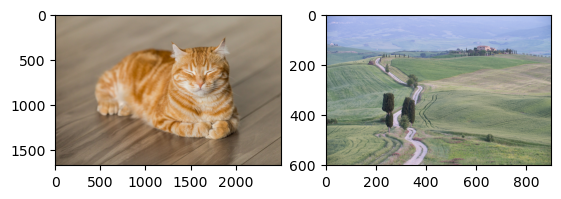

In [4]:
cat_img_rgb  = cv.cvtColor(cat_img, cv.COLOR_BGR2RGB)
landscape_img_rgb = cv.cvtColor(landscape_img, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(cat_img_rgb)
ax[1].imshow(landscape_img_rgb)

In [5]:
height, width = cat_img.shape[:2]
resized_cat_img = cv.resize(cat_img, (224, 224), interpolation=cv.INTER_AREA)
resized_cat_img.shape[:2]

(224, 224)

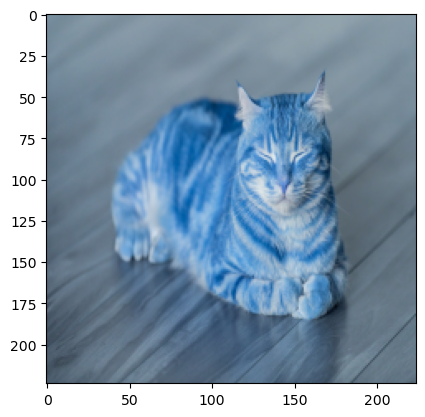

In [6]:
plt.imshow(resized_cat_img)

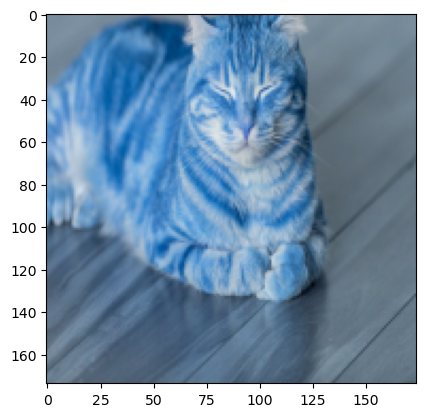

In [7]:
cropped_cat_img = resized_cat_img[50:50+224, 50:50+224]
plt.imshow(cropped_cat_img)

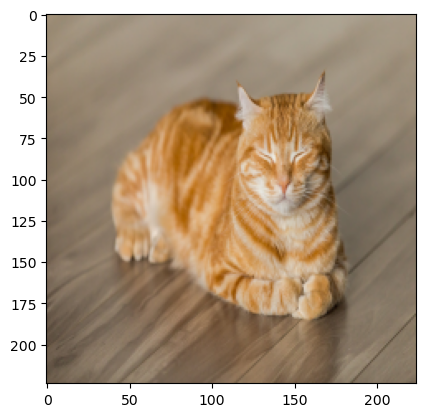

In [8]:
rgb_resized_cat_img = cv.cvtColor(resized_cat_img, cv.COLOR_BGR2RGB)
plt.imshow(rgb_resized_cat_img)

In [9]:
gray_cat_img = cv.cvtColor(resized_cat_img, cv.COLOR_BGR2GRAY)
cv.imshow('gray_cat_img', gray_cat_img)
cv.waitKey(0)
cv.destroyAllWindows()

### Generating Gaussian noise

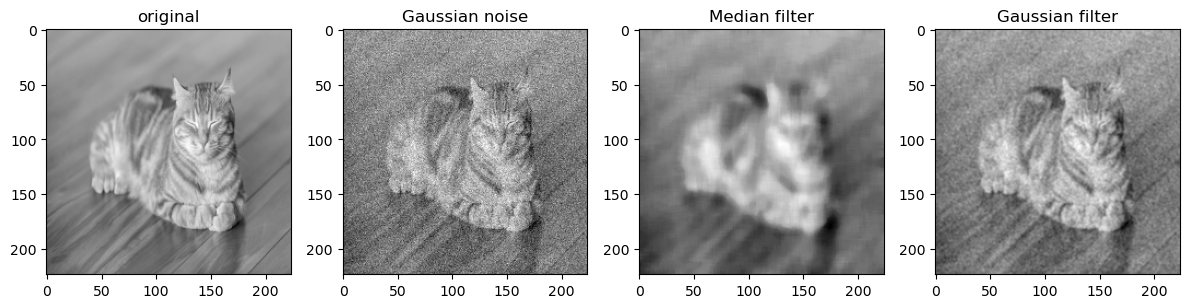

In [74]:
# generating Gaussian noise
gauss_noise = np.random.normal(0, 20, gray_cat_img.shape)
gauss_noise
# add noise to the grayscale image
noise_cat_img_1 = gray_cat_img + gauss_noise
noise_cat_img_1 = np.clip(noise_cat_img_1, 0, 255).astype(np.uint8)
# remove noise using median filter
median_denoise_cat_img_1 = cv.medianBlur(noise_cat_img_1, 11)
gaussian_denoise_cat_img_1 = cv.GaussianBlur(noise_cat_img_1, (3, 3), 0)

# plotting to compare
fig, ax = plt.subplots(1, 4, figsize=(12, 6))
ax[0].imshow(gray_cat_img, cmap='gray')
ax[0].set_title('original')
ax[1].imshow(noise_cat_img_1, cmap='gray')
ax[1].set_title('Gaussian noise')
ax[2].imshow(median_denoise_cat_img_1, cmap='gray')
ax[2].set_title('Median filter')
ax[3].imshow(gaussian_denoise_cat_img_1, cmap='gray')
ax[3].set_title('Gaussian filter')

plt.tight_layout()